In [1]:
from IPython.display import display

from src.visualization import plot_evaluation_dashboard
from src.experiments import run_sampled_dataset_report, save_sampled_dataset_report
from src.experiments import build_synthetic_summary_df, build_synthetic_summary_pivot
from src.experiments import run_synthetic_graph_size_experiments

## 1 Graph Size & Retrieval Methods Analyzis

In [2]:
final_results = run_synthetic_graph_size_experiments(
    graph_sizes=[20, 50, 100],
    retrieval_strategies=["betweenness", "path_aware", "degree"],
    trials_per_size=10,
)

#final_results


Precomputing shared baseline for synthetic_N20 across 10 trials...

=== Dataset: synthetic_N20 | Graph Size N=20 | Strategy: all nodes (baseline) ===
Graph stats: nodes=20 edges=21
[Trial 1] Path 7->18 | Truth: Yes
[Trial 2] Path 6->5 | Truth: Yes
[Trial 3] Path 16->15 | Truth: Yes
[Trial 4] Path 16->6 | Truth: Yes
[Trial 5] Path 19->0 | Truth: Yes
[Trial 6] Path 8->7 | Truth: Yes
[Trial 7] Path 13->6 | Truth: Yes
[Trial 8] Path 2->4 | Truth: Yes
[Trial 9] Path 11->10 | Truth: Yes
[Trial 10] Path 6->15 | Truth: Yes

=== Dataset: synthetic_N20 | Graph Size N=20 | Strategy: betweenness ===
Graph stats: nodes=20 edges=21
[Trial 1] Path 7->18 | Truth: Yes
[Trial 2] Path 6->5 | Truth: Yes
[Trial 3] Path 16->15 | Truth: Yes
[Trial 4] Path 16->6 | Truth: Yes
local_generate retry 1/2 in 2.0s
[Trial 5] Path 19->0 | Truth: Yes
[Trial 6] Path 8->7 | Truth: Yes
[Trial 7] Path 13->6 | Truth: Yes
[Trial 8] Path 2->4 | Truth: Yes
[Trial 9] Path 11->10 | Truth: Yes
[Trial 10] Path 6->15 | Truth: Yes


In [3]:
summary_df = build_synthetic_summary_df(final_results)
display(summary_df.round(2))

pivot = build_synthetic_summary_pivot(summary_df)
print("\nGraph-RAG path fidelity (%) by graph size:")
print(pivot.round(1).to_string())

,N,strategy,trials,baseline_conn_pct,baseline_path_pct,rag_conn_pct,rag_path_pct,conn_delta,path_delta,baseline_conf,rag_conf
0,20,betweenness,10,90.0,50.0,100.0,40.0,10.0,-10.0,0.9,1.0
2,20,degree,10,90.0,50.0,100.0,20.0,10.0,-30.0,0.9,1.0
1,20,path_aware,10,90.0,50.0,100.0,50.0,10.0,0.0,0.9,1.0
3,50,betweenness,10,90.0,20.0,90.0,40.0,0.0,20.0,0.9,1.0
5,50,degree,10,90.0,20.0,100.0,50.0,10.0,30.0,0.9,1.0
4,50,path_aware,10,90.0,20.0,80.0,30.0,-10.0,10.0,0.9,0.8
6,100,betweenness,10,100.0,10.0,100.0,60.0,0.0,50.0,1.0,1.0
8,100,degree,10,100.0,10.0,100.0,30.0,0.0,20.0,1.0,1.0
7,100,path_aware,10,100.0,10.0,100.0,40.0,0.0,30.0,1.0,1.0



Graph-RAG path fidelity (%) by graph size:
strategy  betweenness  degree  path_aware
N                                        
20               40.0    20.0        50.0
50               40.0    50.0        30.0
100              60.0    30.0        40.0


In [ ]:
summary_df = build_synthetic_summary_df(final_results)
display(summary_df.round(2))

pivot = build_synthetic_summary_pivot(summary_df)
print("\nGraph-RAG path fidelity (%) by graph size:")
print(pivot.round(1).to_string())

,N,strategy,trials,baseline_conn_pct,baseline_path_pct,rag_conn_pct,rag_path_pct,conn_delta,path_delta,baseline_conf,rag_conf
0,20,betweenness,10,100.0,20.0,100.0,10.0,0.0,-10.0,1.0,1.0
2,20,degree,10,80.0,20.0,100.0,30.0,20.0,10.0,0.9,1.0
1,20,path_aware,10,80.0,30.0,100.0,80.0,20.0,50.0,0.8,1.0
3,50,betweenness,10,50.0,20.0,100.0,30.0,50.0,10.0,0.9,1.0
5,50,degree,10,90.0,50.0,100.0,30.0,10.0,-20.0,0.9,1.0
4,50,path_aware,10,90.0,40.0,90.0,30.0,0.0,-10.0,1.0,1.0
6,100,betweenness,10,90.0,30.0,100.0,50.0,10.0,20.0,1.0,1.0
8,100,degree,10,90.0,30.0,100.0,40.0,10.0,10.0,1.0,1.0
7,100,path_aware,10,100.0,20.0,100.0,30.0,0.0,10.0,1.0,1.0



Graph-RAG path fidelity (%) by graph size:
strategy  betweenness  degree  path_aware
N                                        
20               10.0    30.0        80.0
50               30.0    30.0        30.0
100              50.0    40.0        30.0


## 2 CORA & FB

In [4]:
report_df, sampled_runs, report_rows = run_sampled_dataset_report(
    trials=10,
    report_datasets=[
        {"graph_name": "cora", "sample_nodes": 300, "trials": 10},
        {"graph_name": "facebook", "sample_nodes": 300, "trials": 10},
    ],
    report_strategies=["betweenness", "path_aware", "degree"],
)

print("\n" + "=" * 110)
print("SAMPLED COMPREHENSIVE REPORT (Cora + Facebook)")
print("=" * 110)
display(report_df.round(2))

Cora Network LCC successfully loaded: 2485 nodes, 5069 edges.

=== CORA sampled run ===
full: nodes=2485 edges=5069 | sampled: nodes=300 edges=577
Precomputing shared baseline for cora_sampled across 10 trials...

=== Dataset: cora_sampled | Graph Size N=300 | Strategy: all nodes (baseline) ===
Graph stats: nodes=300 edges=577
[Trial 1] Path 202->533 | Truth: Yes
[Trial 2] Path 974->262 | Truth: Yes
[Trial 3] Path 186->1475 | Truth: Yes
[Trial 4] Path 423->247 | Truth: Yes
[Trial 5] Path 885->856 | Truth: Yes
[Trial 6] Path 1000->209 | Truth: Yes
[Trial 7] Path 928->1481 | Truth: Yes
[Trial 8] Path 357->189 | Truth: Yes
[Trial 9] Path 1284->976 | Truth: Yes
[Trial 10] Path 1212->988 | Truth: Yes

=== Dataset: cora_sampled | Graph Size N=300 | Strategy: betweenness ===
Graph stats: nodes=300 edges=577
[Trial 1] Path 202->533 | Truth: Yes
[Trial 2] Path 974->262 | Truth: Yes
[Trial 3] Path 186->1475 | Truth: Yes
[Trial 4] Path 423->247 | Truth: Yes
[Trial 5] Path 885->856 | Truth: Yes
[T

,dataset,strategy,trials,sample_nodes,sample_edges,baseline_conn_pct,baseline_path_pct,rag_conn_pct,rag_path_pct,baseline_avg_conf,rag_avg_conf
0,cora,betweenness,10,300,577,60.0,0.0,90.0,30.0,0.9,0.9
1,cora,degree,10,300,577,60.0,0.0,100.0,0.0,0.9,1.0
2,cora,path_aware,10,300,577,60.0,0.0,100.0,0.0,0.9,1.0
3,facebook,betweenness,10,300,4251,80.0,0.0,100.0,50.0,1.0,1.0
4,facebook,degree,10,300,4251,80.0,0.0,100.0,30.0,1.0,1.0
5,facebook,path_aware,10,300,4251,80.0,0.0,100.0,30.0,1.0,1.0


In [12]:
print("Average Graph-RAG metrics by DATASET:")
display(
    report_df.groupby("dataset")[["rag_conn_pct", "rag_path_pct", "rag_avg_conf"]].mean().round(2)
)


print("\nAverage Graph-RAG metrics by STRATEGY:")
display(
    report_df.groupby("strategy")[["rag_conn_pct", "rag_path_pct", "rag_avg_conf"]].mean().round(2)
)

save_sampled_dataset_report(report_rows)

print("\nSaved sampled report to output/comprehensive_report_cora_facebook_sampled.json")

Average Graph-RAG metrics by DATASET:


,rag_conn_pct,rag_path_pct,rag_avg_conf
dataset,,,
cora,96.67,10.00,0.97
facebook,100.00,36.67,1.00



Average Graph-RAG metrics by STRATEGY:


,rag_conn_pct,rag_path_pct,rag_avg_conf
strategy,,,
betweenness,95.0,40.0,0.95
degree,100.0,15.0,1.00
path_aware,100.0,15.0,1.00



Saved sampled report to output/comprehensive_report_cora_facebook_sampled.json


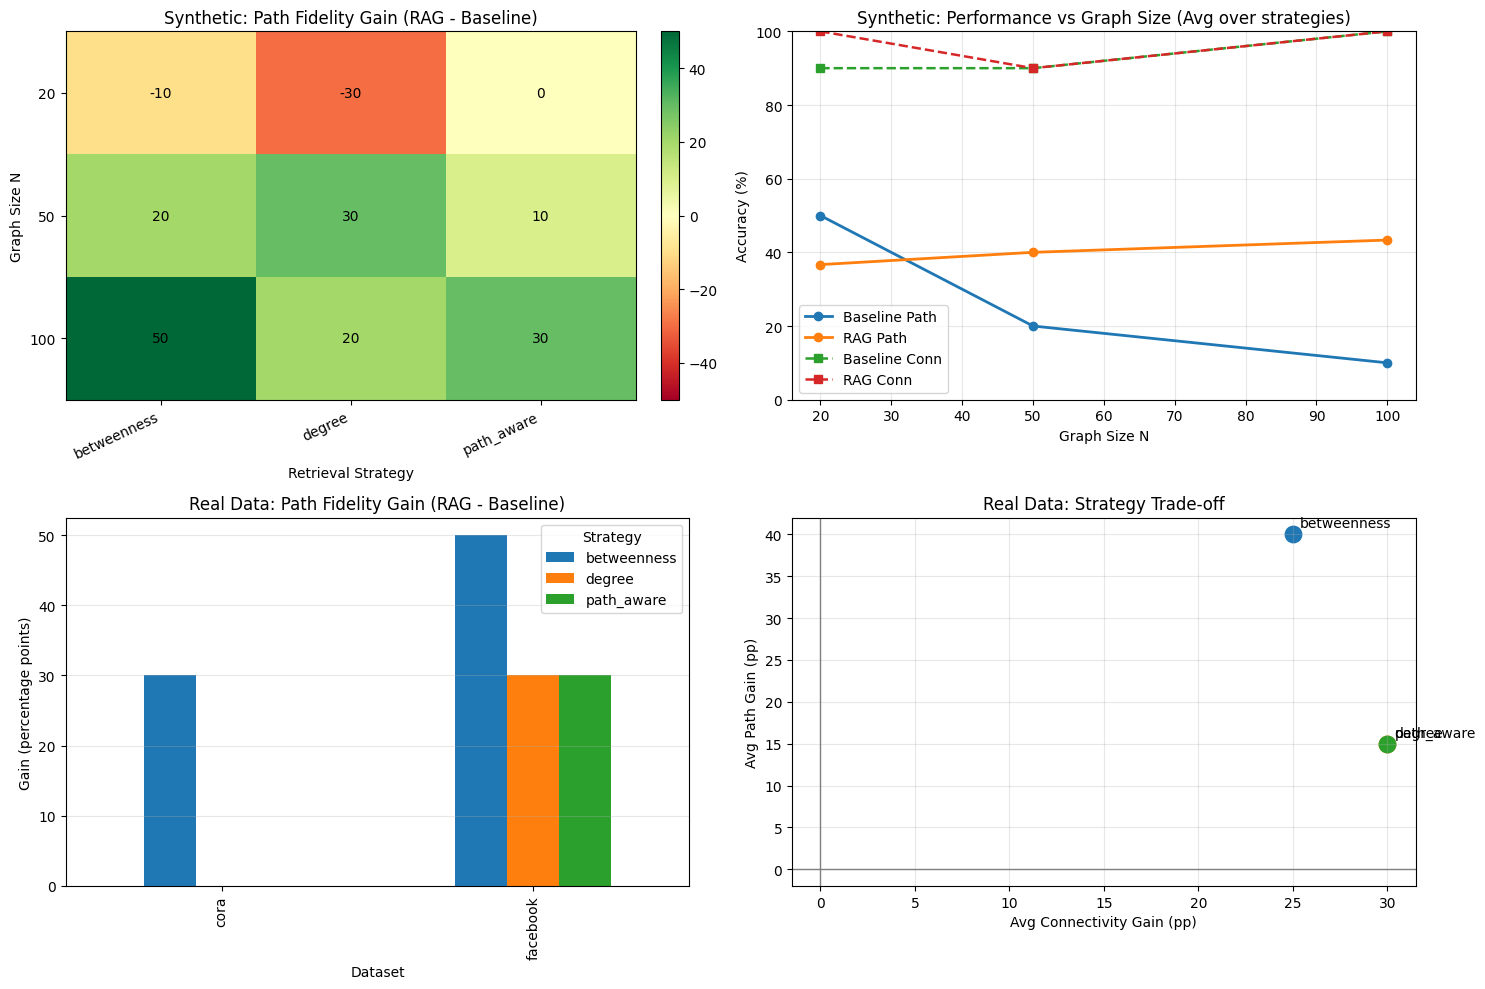

In [13]:
dashboard = plot_evaluation_dashboard(final_results=final_results, report_df=report_df)
synthetic_df = dashboard["synthetic_df"]
tradeoff = dashboard["tradeoff"]

In [11]:
print("Synthetic summary (first rows):")
display(synthetic_df.round(1).head(9))

print("\nReal-data strategy trade-off:")
display(tradeoff.round(1))

Synthetic summary (first rows):


,N,strategy,baseline_conn_pct,baseline_path_pct,rag_conn_pct,rag_path_pct,conn_delta,path_delta
0,20,betweenness,90.0,50.0,100.0,40.0,10.0,-10.0
2,20,degree,90.0,50.0,100.0,20.0,10.0,-30.0
1,20,path_aware,90.0,50.0,100.0,50.0,10.0,0.0
3,50,betweenness,90.0,20.0,90.0,40.0,0.0,20.0
5,50,degree,90.0,20.0,100.0,50.0,10.0,30.0
4,50,path_aware,90.0,20.0,80.0,30.0,-10.0,10.0
6,100,betweenness,100.0,10.0,100.0,60.0,0.0,50.0
8,100,degree,100.0,10.0,100.0,30.0,0.0,20.0
7,100,path_aware,100.0,10.0,100.0,40.0,0.0,30.0



Real-data strategy trade-off:


,strategy,conn_delta,path_delta
0,betweenness,25.0,40.0
1,degree,30.0,15.0
2,path_aware,30.0,15.0


## Test

In [14]:
import json
import pandas as pd

with open("./output/comprehensive_report_cora_facebook_sampled.json", "r", encoding="utf-8") as f:
    report_rows = json.load(f)["rows"]

report_df_2 = pd.DataFrame(report_rows).sort_values(["dataset", "strategy"]).reset_index(drop=True)
report_df_2


,dataset,strategy,trials,sample_nodes,sample_edges,baseline_conn_pct,baseline_path_pct,rag_conn_pct,rag_path_pct,baseline_avg_conf,rag_avg_conf
0,cora,betweenness,10,300,577,60.0,0.0,90.0,30.0,0.9,0.9
1,cora,degree,10,300,577,60.0,0.0,100.0,0.0,0.9,1.0
2,cora,path_aware,10,300,577,60.0,0.0,100.0,0.0,0.9,1.0
3,facebook,betweenness,10,300,4251,80.0,0.0,100.0,50.0,1.0,1.0
4,facebook,degree,10,300,4251,80.0,0.0,100.0,30.0,1.0,1.0
5,facebook,path_aware,10,300,4251,80.0,0.0,100.0,30.0,1.0,1.0


In [15]:
report_df

,dataset,strategy,trials,sample_nodes,sample_edges,baseline_conn_pct,baseline_path_pct,rag_conn_pct,rag_path_pct,baseline_avg_conf,rag_avg_conf
0,cora,betweenness,10,300,577,60.0,0.0,90.0,30.0,0.9,0.9
1,cora,degree,10,300,577,60.0,0.0,100.0,0.0,0.9,1.0
2,cora,path_aware,10,300,577,60.0,0.0,100.0,0.0,0.9,1.0
3,facebook,betweenness,10,300,4251,80.0,0.0,100.0,50.0,1.0,1.0
4,facebook,degree,10,300,4251,80.0,0.0,100.0,30.0,1.0,1.0
5,facebook,path_aware,10,300,4251,80.0,0.0,100.0,30.0,1.0,1.0
